# Window-Level Stimulation vs Accuracy Analysis
### Digit Span Backwards — per cognitive window, STIM ON vs STIM OFF → Accuracy

## Concept
Each trial has multiple time windows. For each window *instance* (e.g. Fixation 1 of Trial 3),  
we ask: **was stimulation on during this window?** Then we look at whether the **trial** was correct.

**Windows analysed:**
| Window | Definition | Notes |
|---|---|---|
| Fixation | `Fixation Start → Stimulus Start` (~1013 ms) | Per digit sub-trial; the meaningful fixation period |
| Stimulus | `Stimulus Start → Stimulus End` (~1004 ms) | Per digit sub-trial; digit on screen |
| Choice | `Choice Start → Choice End` | Once per trial; subject recalls sequence |
| Feedback | `Feedback Start → Feedback End` | Once per trial; result shown |

## Window aggregation rule (Fixation & Stimulus)
A trial has N fixation windows (one per digit). Each sub-window is classified independently as STIM ON or OFF.  
**Within the same trial, only windows with the same stim state are grouped together.**  
If Fixation-1 = STIM ON and Fixation-2 = STIM OFF in the same trial → they go to different groups.  
The accuracy for each window instance is the accuracy of its parent trial.

## Statistics
- **p-value**: Fisher's Exact Test (binary accuracy, small N)
- **Cohen's d**: pooled, treating each window instance as a binary 0/1 observation

## Cell 1 — Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.2,
    'figure.dpi':        150,
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

C_ON  = '#1A56DB'   # STIM ON  → blue
C_OFF = '#90A4AE'   # STIM OFF → grey

# Window colours for figure titles
W_COLORS = {
    'Fixation': '#6A1B9A',
    'Stimulus': '#E65100',
    'Choice':   '#1565C0',
    'Feedback': '#2E7D32',
}

STIM_THRESHOLD = 2.0   # mA
print('Imports OK')

Imports OK


## Cell 2 — File Paths  ← EDIT THESE

In [2]:
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

print('Paths set.')

Paths set.


## Cell 3 — Loading + Alignment Pipeline

In [3]:
def load_session(json_path, csv_path, events_path):
    """
    Returns:
        trials    : list of trial dicts (timing in relative ms)
        bslf_rel  : np.array of mA timestamps (relative ms)
        bslf_mA   : np.array of mA values
        meta      : dict(subject, session, date)
    """
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    subject = str(df['Subject'].iloc[0])
    session = str(df['Session'].iloc[0])
    date    = str(df['SessionDate'].iloc[0])

    # ── Alignment anchor: find first 0→>0 mA transition ──────────────────────
    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick:
            break
    assert stim_start_tick, 'No 0→>0 mA transition found!'

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(ms):       return float(ms) + MANUAL_OFFSET - stim_start_tick
    def tick_to_rel(arr): return np.asarray(arr, dtype=float) - stim_start_tick

    # ── mA trace ──────────────────────────────────────────────────────────────
    bslf_tick, bslf_mA = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            bslf_tick.append(pkt['TicksInMs'])
            bslf_mA.append(pkt['Left']['mA'])
    bslf_rel = tick_to_rel(np.array(bslf_tick, dtype=float))
    bslf_mA  = np.array(bslf_mA, dtype=float)

    # ── Helper: first occurrence of event type for a trial ────────────────────
    def ev_first(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
        return to_rel(float(rows.iloc[0]['Time_ms'])) if len(rows) else None

    def ev_all(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
        return [to_rel(float(r['Time_ms'])) for _, r in rows.iterrows()]

    # ── Build trial list ──────────────────────────────────────────────────────
    trials = []
    for tn in range(1, 15):
        sr = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if sr.empty:
            continue
        r = sr.iloc[0]

        acc    = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        digits = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None

        t = dict(
            num    = tn,
            acc    = acc,
            digits = digits,
            # ── single-occurrence windows ─────────────────────────────────────
            choice_start   = ev_first('Choice Start',   tn),
            choice_end     = ev_first('Choice End',     tn),
            feedback_start = ev_first('Feedback Start', tn),
            feedback_end   = ev_first('Feedback End',   tn),
            # ── per-digit sub-windows ─────────────────────────────────────────
            # Fixation window = Fixation Start → Stimulus Start (~1013ms, meaningful period)
            # Stimulus window = Stimulus Start → Stimulus End   (~1004ms, digit on screen)
            fix_starts  = ev_all('Fixation Start',  tn),
            stim_starts = ev_all('Stimulus Start',  tn),
            stim_ends   = ev_all('Stimulus End',    tn),
        )
        trials.append(t)

    meta = dict(subject=subject, session=session, date=date)
    print(f'Loaded: Subject={subject}  Session={session}  Date={date}  Trials={len(trials)}')
    return trials, bslf_rel, bslf_mA, meta


print('load_session defined.')

load_session defined.


## Cell 4 — Window Stim Classification

For each window instance, compute what fraction of its duration has mA ≥ threshold.  
Tag as **STIM ON** if ≥ 50% of the window duration is stimulated.

In [4]:
def stim_fraction(t_start, t_end, bslf_rel, bslf_mA, threshold=STIM_THRESHOLD):
    """
    Returns fraction of [t_start, t_end] where mA >= threshold.

    Fallback: if fewer than 2 mA samples fall inside the window
    (can happen when the Medtronic mA trace is coarsely sampled),
    we use the single nearest mA sample to the window midpoint.
    That sample's value determines stim_on (0.0 or 1.0).
    This ensures no valid window is silently dropped.

    Returns NaN only if t_start/t_end are None or window is zero-length.
    """
    if t_start is None or t_end is None:
        return np.nan
    if t_end <= t_start:
        return np.nan
    mask = (bslf_rel >= t_start) & (bslf_rel <= t_end)
    t_r  = bslf_rel[mask]
    t_m  = bslf_mA[mask]
    if len(t_r) < 2:
        # Fallback: find nearest mA sample to window midpoint
        midpoint = (t_start + t_end) / 2.0
        idx = int(np.argmin(np.abs(bslf_rel - midpoint)))
        nearest_mA = bslf_mA[idx]
        return 1.0 if nearest_mA >= threshold else 0.0
    dt     = np.diff(t_r)
    mid_mA = (t_m[:-1] + t_m[1:]) / 2.0
    total  = t_r[-1] - t_r[0]
    if total <= 0:
        # Single sample inside window — use it directly
        return 1.0 if t_m[0] >= threshold else 0.0
    return float(np.sum(dt[mid_mA >= threshold]) / total)


def build_window_df(trials, bslf_rel, bslf_mA, sess_label, threshold=STIM_THRESHOLD):
    """
    Returns a tidy DataFrame: one row per window instance.

    Columns:
        session, trial_num, digits, acc, window_type,
        sub_idx,          # 0-based digit index for Fixation/Stimulus; 0 for Choice/Feedback
        t_start, t_end,   # window boundaries in relative ms
        stim_frac,        # fraction of window that is stimulated
        stim_on           # bool: stim_frac >= 0.5

    Fixation window rule:
        Fixation window i = fix_starts[i] → stim_starts[i]  (the ~1013ms meaningful period)
        Only created when both fix_starts[i] and stim_starts[i] exist.

    Stimulus window rule:
        Stimulus window i = stim_starts[i] → stim_ends[i]
        Only created when both exist.

    Per-trial same-trial rule (as requested):
        Sub-windows within a trial are classified independently.
        Fixation-1 ON and Fixation-2 OFF → two separate rows in different stim groups.
        This is the natural consequence of per-instance classification.
    """
    rows = []

    for t in trials:
        if t['acc'] is None:
            continue

        base = dict(
            session   = sess_label,
            trial_num = t['num'],
            digits    = t['digits'],
            acc       = t['acc'],
        )

        # ── Fixation windows (one per digit): Fixation Start → Stimulus Start ──
        for i, (fs, ss) in enumerate(zip(t['fix_starts'], t['stim_starts'])):
            frac = stim_fraction(fs, ss, bslf_rel, bslf_mA, threshold)
            if np.isnan(frac):
                continue
            rows.append({**base,
                'window_type': 'Fixation',
                'sub_idx':     i,
                't_start':     fs,
                't_end':       ss,
                'stim_frac':   frac,
                'stim_on':     frac >= 0.5,
            })

        # ── Stimulus windows (one per digit): Stimulus Start → Stimulus End ────
        for i, (ss, se) in enumerate(zip(t['stim_starts'], t['stim_ends'])):
            frac = stim_fraction(ss, se, bslf_rel, bslf_mA, threshold)
            if np.isnan(frac):
                continue
            rows.append({**base,
                'window_type': 'Stimulus',
                'sub_idx':     i,
                't_start':     ss,
                't_end':       se,
                'stim_frac':   frac,
                'stim_on':     frac >= 0.5,
            })

        # ── Choice window (once per trial) ────────────────────────────────────
        frac = stim_fraction(t['choice_start'], t['choice_end'],
                             bslf_rel, bslf_mA, threshold)
        if not np.isnan(frac):
            rows.append({**base,
                'window_type': 'Choice',
                'sub_idx':     0,
                't_start':     t['choice_start'],
                't_end':       t['choice_end'],
                'stim_frac':   frac,
                'stim_on':     frac >= 0.5,
            })

        # ── Feedback window (once per trial) ──────────────────────────────────
        frac = stim_fraction(t['feedback_start'], t['feedback_end'],
                             bslf_rel, bslf_mA, threshold)
        if not np.isnan(frac):
            rows.append({**base,
                'window_type': 'Feedback',
                'sub_idx':     0,
                't_start':     t['feedback_start'],
                't_end':       t['feedback_end'],
                'stim_frac':   frac,
                'stim_on':     frac >= 0.5,
            })

    df = pd.DataFrame(rows)
    print(f'{sess_label}: {len(df)} window instances '
          f'({df["stim_on"].sum()} STIM ON, {(~df["stim_on"]).sum()} STIM OFF)')
    return df


print('Window classification functions defined.')

Window classification functions defined.


## Cell 5 — Statistics Functions

In [5]:
def fisher_exact_p(n_corr_a, n_a, n_corr_b, n_b):
    """Fisher's Exact p-value: ON vs OFF."""
    if n_a == 0 or n_b == 0:
        return np.nan
    table = [[n_corr_a, n_a - n_corr_a],
             [n_corr_b, n_b - n_corr_b]]
    _, p = stats.fisher_exact(table)
    return float(p)


def cohens_d_binary(scores_a, scores_b):
    """
    Pooled Cohen's d on binary (0/1) arrays.
    pooled_sd = sqrt( [(na-1)*var_a + (nb-1)*var_b] / (na+nb-2) )
    d = (mean_a - mean_b) / pooled_sd
    Returns NaN when pooled_sd = 0 or insufficient N.
    """
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    var_a = np.var(a, ddof=1)
    var_b = np.var(b, ddof=1)
    pooled_var = ((len(a) - 1) * var_a + (len(b) - 1) * var_b) / (len(a) + len(b) - 2)
    pooled_sd  = np.sqrt(pooled_var)
    if pooled_sd == 0:
        return np.nan
    return float((np.mean(a) - np.mean(b)) / pooled_sd)


def d_label(d):
    if np.isnan(d): return 'N/A'
    v = abs(d)
    if v >= 0.8:  return 'large'
    if v >= 0.5:  return 'medium'
    if v >= 0.2:  return 'small'
    return 'negligible'


def sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'


def compute_window_stats(df_w):
    """
    Given a subset DataFrame for one window type (already filtered),
    returns dict with all stats.
    """
    on  = df_w[df_w['stim_on'] == True]['acc'].dropna().values
    off = df_w[df_w['stim_on'] == False]['acc'].dropna().values

    n_on,  n_corr_on  = len(on),  int(on.sum())  if len(on)  else (0, 0)
    n_off, n_corr_off = len(off), int(off.sum()) if len(off) else (0, 0)

    acc_on  = on.mean()  if n_on  > 0 else np.nan
    acc_off = off.mean() if n_off > 0 else np.nan

    p = fisher_exact_p(n_corr_on, n_on, n_corr_off, n_off)
    d = cohens_d_binary(on, off)

    return dict(
        on=on, off=off,
        n_on=n_on,   n_corr_on=n_corr_on,   acc_on=acc_on,
        n_off=n_off, n_corr_off=n_corr_off, acc_off=acc_off,
        p=p, d=d,
    )


print('Stats functions defined.')

Stats functions defined.


## Cell 6 — Load Sessions + Build Window DataFrames

In [6]:
# ── Load sessions ─────────────────────────────────────────────────────────────
trials_s2, bslf_rel_s2, bslf_mA_s2, meta_s2 = load_session(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2)

trials_s3, bslf_rel_s3, bslf_mA_s3, meta_s3 = load_session(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3)

# ── Build per-window DataFrames ───────────────────────────────────────────────
print()
wdf_s2  = build_window_df(trials_s2, bslf_rel_s2, bslf_mA_s2, 'Session 2')
wdf_s3  = build_window_df(trials_s3, bslf_rel_s3, bslf_mA_s3, 'Session 3')
wdf_all = pd.concat([wdf_s2, wdf_s3], ignore_index=True)

print(f'\nCombined: {len(wdf_all)} window instances total')

# ── Quick sanity check: counts per window type ────────────────────────────────
print('\nWindow instance counts per type:')
for wname in ['Fixation', 'Stimulus', 'Choice', 'Feedback']:
    for slbl, df in [('S2', wdf_s2), ('S3', wdf_s3), ('Combined', wdf_all)]:
        sub = df[df['window_type'] == wname]
        n_on  = (sub['stim_on'] == True).sum()
        n_off = (sub['stim_on'] == False).sum()
        print(f'  {wname:<10} {slbl:<10} ON={n_on:>3}  OFF={n_off:>3}  total={len(sub):>3}')

Loaded: Subject=6  Session=2  Date=03-05-2026  Trials=14
Loaded: Subject=6  Session=3  Date=03-05-2026  Trials=14

Session 2: 128 window instances (81 STIM ON, 47 STIM OFF)
Session 3: 108 window instances (22 STIM ON, 86 STIM OFF)

Combined: 236 window instances total

Window instance counts per type:
  Fixation   S2         ON= 32  OFF= 18  total= 50
  Fixation   S3         ON=  9  OFF= 31  total= 40
  Fixation   Combined   ON= 41  OFF= 49  total= 90
  Stimulus   S2         ON= 33  OFF= 17  total= 50
  Stimulus   S3         ON=  6  OFF= 34  total= 40
  Stimulus   Combined   ON= 39  OFF= 51  total= 90
  Choice     S2         ON=  8  OFF=  6  total= 14
  Choice     S3         ON=  2  OFF= 12  total= 14
  Choice     Combined   ON= 10  OFF= 18  total= 28
  Feedback   S2         ON=  8  OFF=  6  total= 14
  Feedback   S3         ON=  5  OFF=  9  total= 14
  Feedback   Combined   ON= 13  OFF= 15  total= 28


## Cell 7 — Print Stats Tables

In [7]:
WINDOWS = ['Fixation', 'Stimulus', 'Choice', 'Feedback']

for sess_label, df in [('Session 2', wdf_s2), ('Session 3', wdf_s3),
                        ('Combined (S2+S3)', wdf_all)]:
    print(f'\n{"="*80}')
    print(f'  {sess_label}')
    print(f'  p = Fisher\'s Exact   d = pooled Cohen\'s d on binary accuracy')
    print(f'{"="*80}')
    print(f'  {"Window":<12} {"STIM ON":>18}  {"STIM OFF":>18}  {"p-value":>10}  {"Stars":<5}  {"d":>8}  Effect')
    print(f'  {"-"*75}')

    for w in WINDOWS:
        sub = df[df['window_type'] == w]
        if len(sub) == 0:
            print(f'  {w:<12}  no data')
            continue
        c = compute_window_stats(sub)

        on_s  = (f"{c['n_corr_on']}/{c['n_on']} ({c['acc_on']*100:.1f}%)"
                 if c['n_on'] > 0 else '—')
        off_s = (f"{c['n_corr_off']}/{c['n_off']} ({c['acc_off']*100:.1f}%)"
                 if c['n_off'] > 0 else '—')
        p_s   = f"{c['p']:.4f}" if not np.isnan(c['p']) else 'N/A'
        d_s   = f"{c['d']:+.3f}" if not np.isnan(c['d']) else 'N/A'

        print(f'  {w:<12} {on_s:>18}  {off_s:>18}  {p_s:>10}  '
              f'{sig_stars(c["p"]):<5}  {d_s:>8}  ({d_label(c["d"])})')
    print()


  Session 2
  p = Fisher's Exact   d = pooled Cohen's d on binary accuracy
  Window                  STIM ON            STIM OFF     p-value  Stars         d  Effect
  ---------------------------------------------------------------------------
  Fixation           5/32 (15.6%)       13/18 (72.2%)      0.0001  ***      -1.401  (large)
  Stimulus           5/33 (15.2%)       13/17 (76.5%)      0.0000  ***      -1.572  (large)
  Choice              1/8 (12.5%)         5/6 (83.3%)      0.0256  *        -1.877  (large)
  Feedback            1/8 (12.5%)         5/6 (83.3%)      0.0256  *        -1.877  (large)


  Session 3
  p = Fisher's Exact   d = pooled Cohen's d on binary accuracy
  Window                  STIM ON            STIM OFF     p-value  Stars         d  Effect
  ---------------------------------------------------------------------------
  Fixation            3/9 (33.3%)       19/31 (61.3%)      0.2534  ns       -0.563  (medium)
  Stimulus            3/6 (50.0%)       19/34 (5

## Cell 8 — Plot Function: STIM ON vs OFF per Window

One figure per session scope.  
4 subplots, one per window (Fixation / Stimulus / Choice / Feedback).  
Each subplot: blue bar (ON) vs grey bar (OFF), individual instance dots, bracket with p + d.

In [8]:
def plot_windows(df, sess_label, save_path=None):
    """
    4-panel figure: one subplot per cognitive window.
    Each subplot: STIM ON vs STIM OFF accuracy with p-value + Cohen's d.
    """
    windows = ['Fixation', 'Stimulus', 'Choice', 'Feedback']
    fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False,
                             facecolor='white')

    for ax, w in zip(axes, windows):
        sub = df[df['window_type'] == w]
        wc  = W_COLORS.get(w, '#555')

        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')
            ax.set_title(w, fontsize=12, fontweight='bold', color=wc)
            continue

        c = compute_window_stats(sub)

        acc_on  = c['acc_on']  * 100 if not np.isnan(c['acc_on'])  else 0
        acc_off = c['acc_off'] * 100 if not np.isnan(c['acc_off']) else 0

        # ── binomial SE ───────────────────────────────────────────────────────
        se_on  = (np.sqrt(c['acc_on']  * (1 - c['acc_on'])  / c['n_on'])  * 100
                  if c['n_on']  > 1 and not np.isnan(c['acc_on'])  else 0)
        se_off = (np.sqrt(c['acc_off'] * (1 - c['acc_off']) / c['n_off']) * 100
                  if c['n_off'] > 1 and not np.isnan(c['acc_off']) else 0)

        # ── bars ──────────────────────────────────────────────────────────────
        ax.bar([0, 1], [acc_on, acc_off], width=0.50,
               color=[C_ON, C_OFF], zorder=3, edgecolor='white', linewidth=1.5)
        ax.errorbar([0, 1], [acc_on, acc_off],
                    yerr=[se_on, se_off], fmt='none',
                    color='#333', capsize=6, lw=2, zorder=4)

        # ── individual window instance dots ───────────────────────────────────
        rng = np.random.default_rng(seed=42)
        for xi, scores in [(0, c['on']), (1, c['off'])]:
            jitter = rng.uniform(-0.09, 0.09, size=len(scores))
            ax.scatter(xi + jitter, scores * 100,
                       color='black', s=26, zorder=5, alpha=0.60)

        # ── count labels ──────────────────────────────────────────────────────
        for xi, nc, nt, acc, se in [
                (0, c['n_corr_on'],  c['n_on'],  acc_on,  se_on),
                (1, c['n_corr_off'], c['n_off'], acc_off, se_off)]:
            ax.text(xi, acc + se + 6,
                    f'{nc}/{nt}\n({acc:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        # ── significance bracket with p + Cohen's d ───────────────────────────
        y_top = max(acc_on + se_on, acc_off + se_off) + 18
        y_top = min(y_top, 118)
        pad   = 3
        p_val = c['p']
        d_val = c['d']

        bracket_col = '#D32F2F' if (not np.isnan(p_val) and p_val < 0.05) else '#9E9E9E'
        ax.plot([0, 0, 1, 1],
                [y_top, y_top+pad, y_top+pad, y_top],
                lw=1.4, color=bracket_col, zorder=6)

        p_str = f'p={p_val:.4f}' if not np.isnan(p_val) else 'p=N/A'
        d_str = (f'd={d_val:+.2f} ({d_label(d_val)})'
                 if not np.isnan(d_val) else 'd=N/A')
        ax.text(0.5, y_top + pad*1.5,
                f'{sig_stars(p_val)}\n{p_str}\n{d_str}',
                ha='center', va='bottom', fontsize=8.5,
                color=bracket_col, fontweight='bold', zorder=7)

        # ── axes ──────────────────────────────────────────────────────────────
        ax.set_xlim(-0.6, 1.6)
        ax.set_ylim(-10, 148)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['STIM ON', 'STIM OFF'], fontsize=11)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_ylabel('Trial Accuracy (%)', fontsize=10)
        ax.axhline(50, color='#ddd', lw=1, ls='--', zorder=1)
        ax.yaxis.grid(True, color='#eee', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('white')

        n_on_w  = c['n_on']
        n_off_w = c['n_off']
        ax.set_title(
            f'{w} Window\n'
            f'(ON={n_on_w} instances, OFF={n_off_w} instances)',
            fontsize=11, fontweight='bold', color=wc
        )

    # ── figure legend + title ─────────────────────────────────────────────────
    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON  (≥50% of window)'),
        mpatches.Patch(color=C_OFF, label='STIM OFF (<50% of window)'),
    ]
    fig.legend(handles=handles, fontsize=10, loc='lower center',
               ncol=2, framealpha=0.92, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(
        f'Stimulation vs Accuracy by Cognitive Window\n{sess_label}',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    plt.close(fig)


print('plot_windows defined.')

plot_windows defined.


## Cell 9 — Session 2 Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\window_stim_accuracy_S2.png


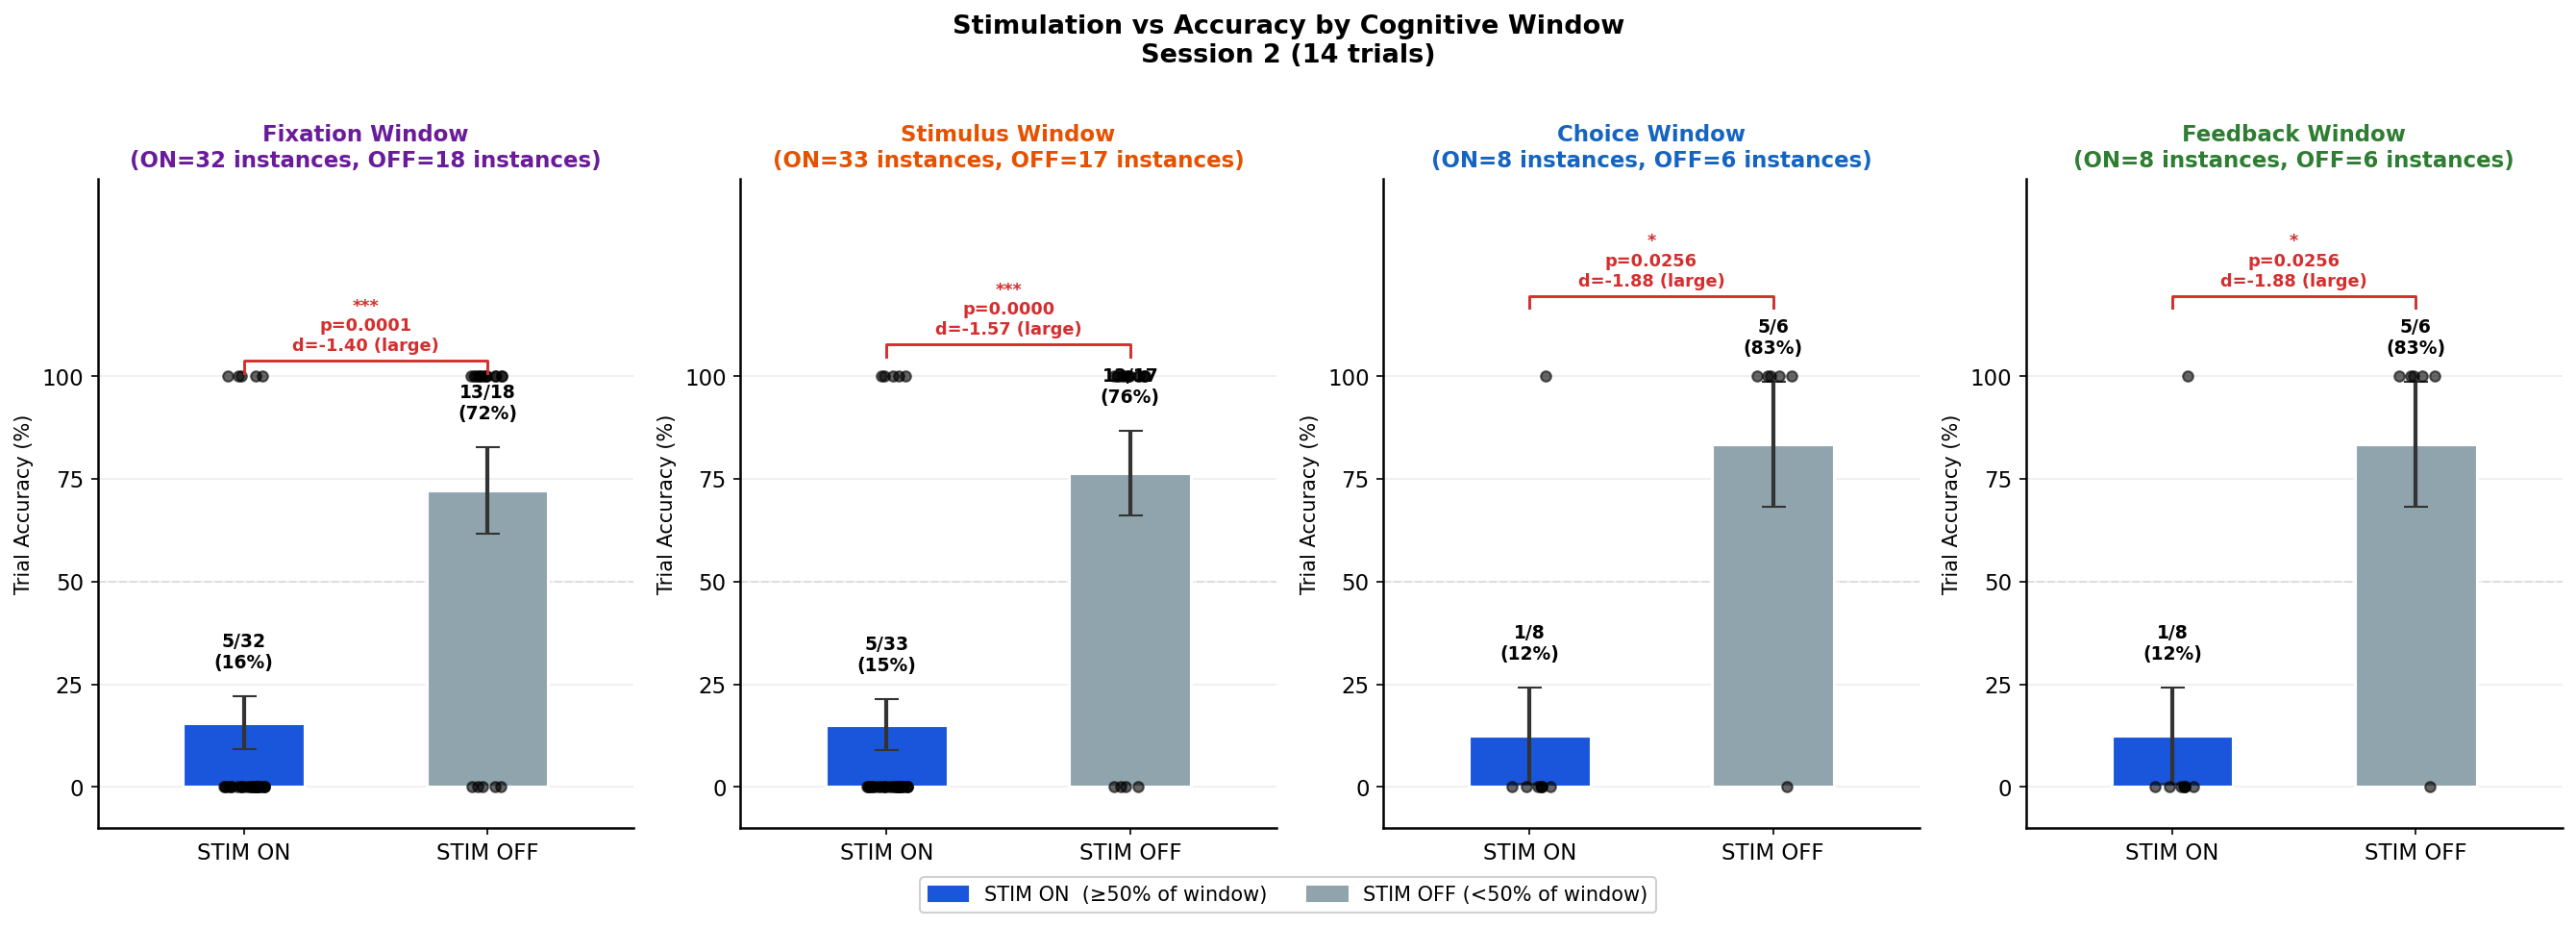

In [9]:
plot_windows(
    wdf_s2,
    sess_label='Session 2 (14 trials)',
    save_path=OUT_DIR_S2 / 'window_stim_accuracy_S2.png'
)

## Cell 10 — Session 3 Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\window_stim_accuracy_S3.png


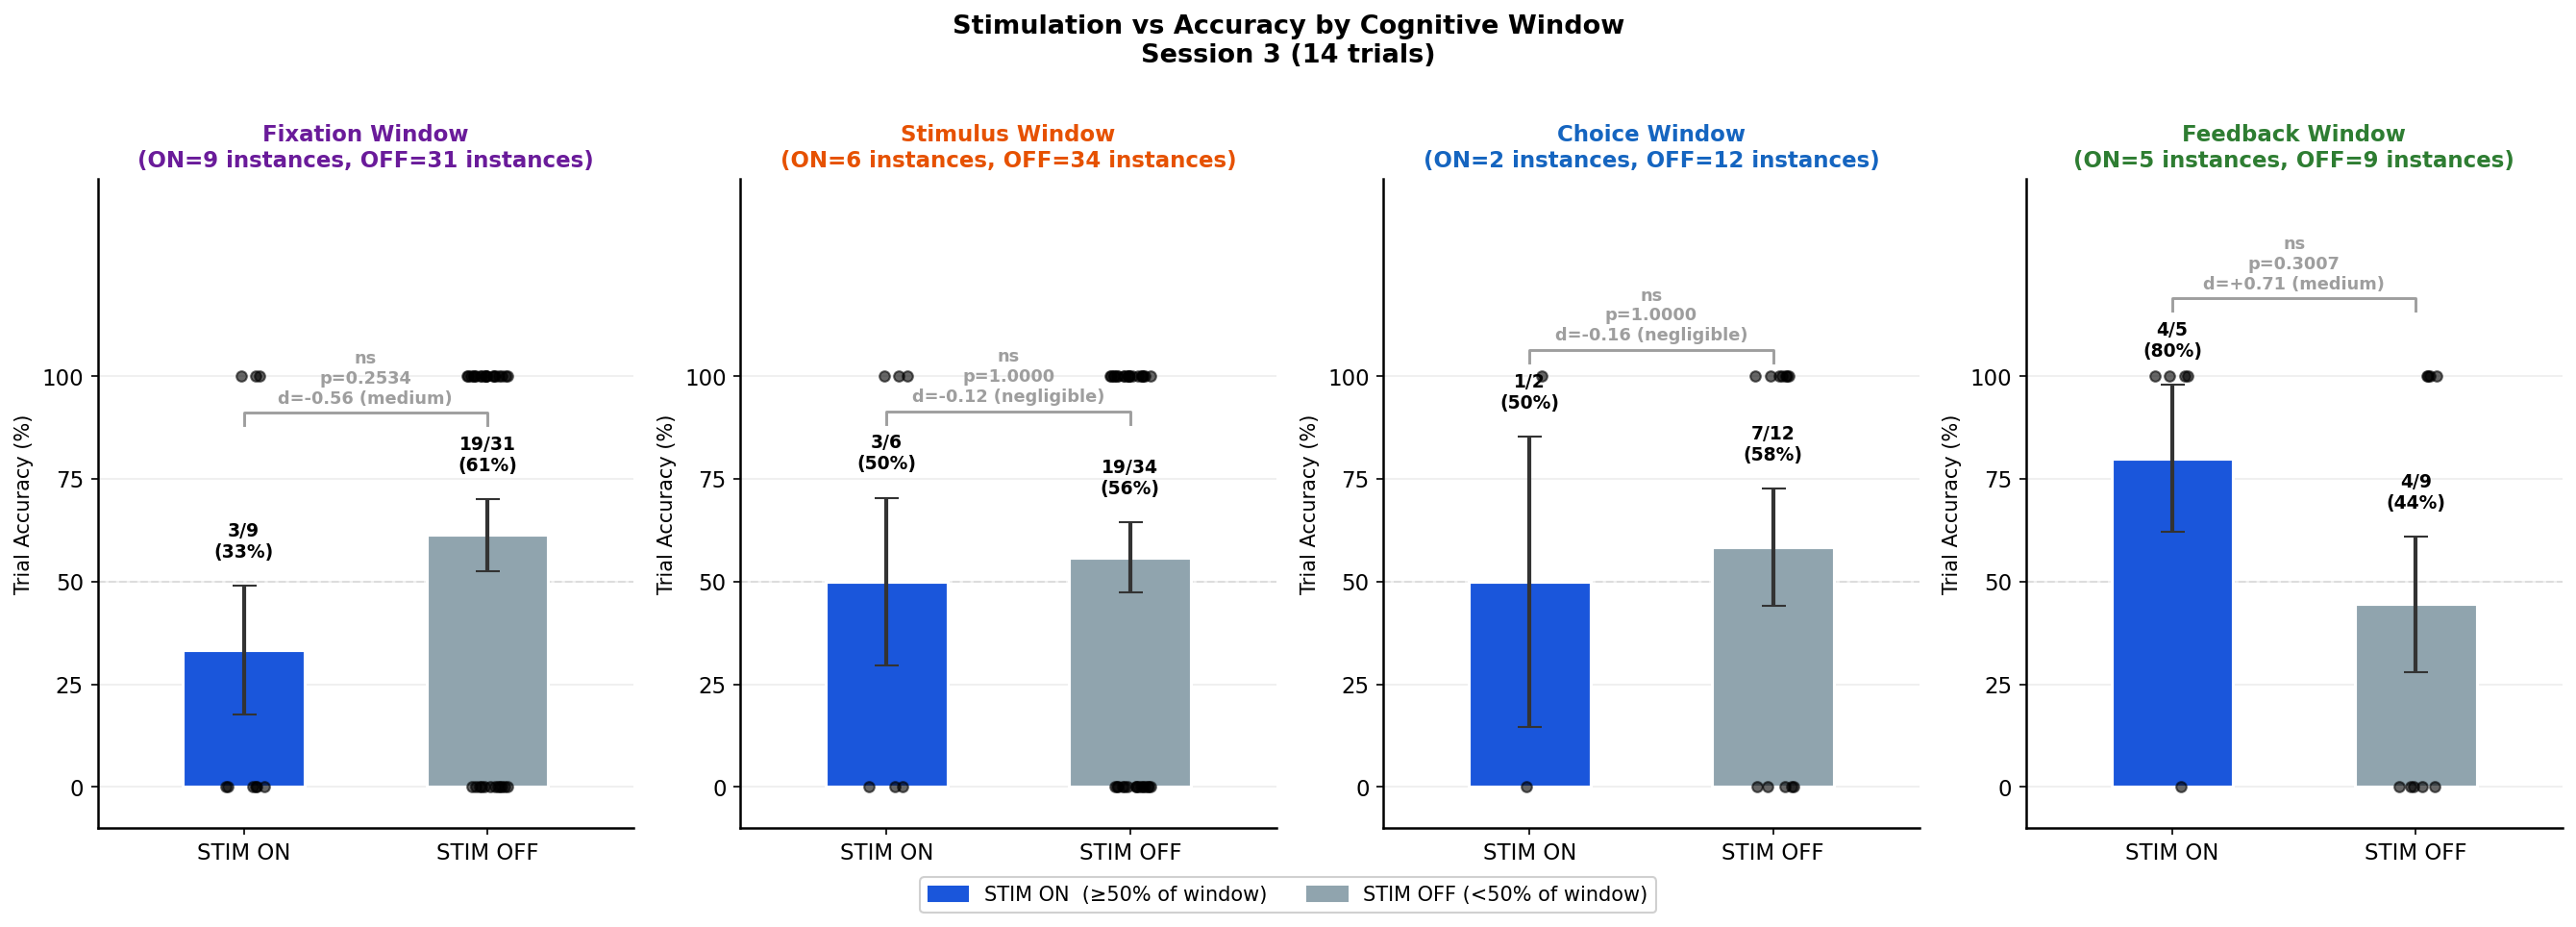

In [10]:
plot_windows(
    wdf_s3,
    sess_label='Session 3 (14 trials)',
    save_path=OUT_DIR_S3 / 'window_stim_accuracy_S3.png'
)

## Cell 11 — Combined (S2 + S3) Plot

In [ ]:
plot_windows(
    wdf_all,
    sess_label='Combined: Session 2 + Session 3',
    save_path=COMBINED_DIR / 'window_stim_accuracy_combined.png'
)

## Cell 12 — Per-Window Breakdown Plot (by digit count)

Same 4-window layout but split by digit count (2 / 3 / 4 digits).  
Useful to see if the stim effect is consistent across difficulty levels.

In [ ]:
def plot_windows_by_digits(df, sess_label, save_path=None,
                            digit_levels=None, windows=None):
    """
    Grid: rows = windows, columns = digit counts.
    Each cell: STIM ON vs STIM OFF bar + p + d.
    """
    if windows is None:
        windows = ['Fixation', 'Stimulus', 'Choice', 'Feedback']
    if digit_levels is None:
        digit_levels = sorted([d for d in df['digits'].unique()
                                if d in [2, 3, 4, 5] and pd.notna(d)])

    n_rows = len(windows)
    n_cols = len(digit_levels)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3.8, n_rows * 4.2),
                             sharey='row', facecolor='white')
    # Normalise axes to 2D array
    if n_rows == 1: axes = axes[np.newaxis, :]
    if n_cols == 1: axes = axes[:, np.newaxis]

    DIFF_LABELS = {2: 'Easy (2d)', 3: 'Medium (3d)', 4: 'Hard (4d)', 5: 'God (5d)'}

    for ri, w in enumerate(windows):
        wc = W_COLORS.get(w, '#555')
        for ci, d in enumerate(digit_levels):
            ax  = axes[ri][ci]
            sub = df[(df['window_type'] == w) & (df['digits'] == d)]

            if ri == 0:
                ax.set_title(DIFF_LABELS.get(d, f'{d}d'),
                             fontsize=10.5, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'{w}\nAccuracy (%)', fontsize=9,
                              color=wc, fontweight='bold')

            if len(sub) == 0:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='grey')
                ax.set_xticks([])
                continue

            c = compute_window_stats(sub)

            acc_on  = c['acc_on']  * 100 if not np.isnan(c['acc_on'])  else 0
            acc_off = c['acc_off'] * 100 if not np.isnan(c['acc_off']) else 0
            se_on  = (np.sqrt(c['acc_on']  * (1 - c['acc_on'])  / c['n_on'])  * 100
                      if c['n_on']  > 1 and not np.isnan(c['acc_on'])  else 0)
            se_off = (np.sqrt(c['acc_off'] * (1 - c['acc_off']) / c['n_off']) * 100
                      if c['n_off'] > 1 and not np.isnan(c['acc_off']) else 0)

            ax.bar([0, 1], [acc_on, acc_off], width=0.50,
                   color=[C_ON, C_OFF], zorder=3, edgecolor='white')
            ax.errorbar([0, 1], [acc_on, acc_off],
                        yerr=[se_on, se_off], fmt='none',
                        color='#333', capsize=4, lw=1.5, zorder=4)

            # individual dots
            rng = np.random.default_rng(seed=42)
            for xi, scores in [(0, c['on']), (1, c['off'])]:
                jitter = rng.uniform(-0.09, 0.09, size=len(scores))
                ax.scatter(xi + jitter, scores * 100,
                           color='black', s=18, zorder=5, alpha=0.55)

            # count labels
            for xi, nc, nt, acc in [(0, c['n_corr_on'],  c['n_on'],  acc_on),
                                     (1, c['n_corr_off'], c['n_off'], acc_off)]:
                ax.text(xi, min(acc + 8, 108),
                        f'{nc}/{nt}', ha='center', va='bottom',
                        fontsize=7.5, fontweight='bold')

            # bracket
            y_top = max(acc_on + se_on, acc_off + se_off) + 15
            y_top = min(y_top, 115)
            pad   = 2.5
            p_val = c['p']
            d_val = c['d']
            bcol  = '#D32F2F' if (not np.isnan(p_val) and p_val < 0.05) else '#9E9E9E'
            ax.plot([0, 0, 1, 1],
                    [y_top, y_top+pad, y_top+pad, y_top],
                    lw=1.2, color=bcol, zorder=6)

            p_str = f'p={p_val:.3f}' if not np.isnan(p_val) else 'p=N/A'
            d_str = f'd={d_val:+.2f}' if not np.isnan(d_val) else 'd=N/A'
            ax.text(0.5, y_top + pad*1.2,
                    f'{sig_stars(p_val)}  {p_str}\n{d_str}',
                    ha='center', va='bottom', fontsize=7.5,
                    color=bcol, fontweight='bold', zorder=7)

            ax.set_xlim(-0.6, 1.6)
            ax.set_ylim(-8, 140)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['ON', 'OFF'], fontsize=9)
            ax.set_yticks([0, 50, 100])
            ax.axhline(50, color='#ddd', lw=0.8, ls='--', zorder=1)
            ax.yaxis.grid(True, color='#eee', zorder=0)
            ax.set_axisbelow(True)
            ax.set_facecolor('white')

    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON  (≥50% of window)'),
        mpatches.Patch(color=C_OFF, label='STIM OFF (<50% of window)'),
    ]
    fig.legend(handles=handles, fontsize=9, loc='lower center',
               ncol=2, framealpha=0.92, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(
        f'Stim vs Accuracy: Window × Difficulty\n{sess_label}',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    plt.close(fig)


print('plot_windows_by_digits defined.')

## Cell 13 — Window × Difficulty Grid Plots

In [ ]:
for lbl, df, odir in [
    ('Session 2 (14 trials)',              wdf_s2,  OUT_DIR_S2),
    ('Session 3 (14 trials)',              wdf_s3,  OUT_DIR_S3),
    ('Combined: Session 2 + Session 3',    wdf_all, COMBINED_DIR),
]:
    plot_windows_by_digits(
        df, lbl,
        save_path=Path(odir) / f'window_x_difficulty_{lbl[:9].replace(" ","_")}.png'
    )

## Cell 14 — Summary Table

In [ ]:
rows = []
for sess_label, df in [('Session 2', wdf_s2), ('Session 3', wdf_s3),
                        ('Combined',  wdf_all)]:
    for w in ['Fixation', 'Stimulus', 'Choice', 'Feedback']:
        sub = df[df['window_type'] == w]
        if len(sub) == 0:
            continue
        c = compute_window_stats(sub)
        rows.append(dict(
            Session     = sess_label,
            Window      = w,
            N_ON        = c['n_on'],
            Correct_ON  = c['n_corr_on'],
            Acc_ON      = f"{c['acc_on']*100:.1f}%" if not np.isnan(c['acc_on'])  else '—',
            N_OFF       = c['n_off'],
            Correct_OFF = c['n_corr_off'],
            Acc_OFF     = f"{c['acc_off']*100:.1f}%" if not np.isnan(c['acc_off']) else '—',
            p_value     = f"{c['p']:.4f}" if not np.isnan(c['p']) else 'N/A',
            Sig         = sig_stars(c['p']),
            Cohens_d    = f"{c['d']:+.3f}" if not np.isnan(c['d']) else 'N/A',
            Effect_Size = d_label(c['d']),
        ))

summary_df = pd.DataFrame(rows)
display(summary_df)

summary_df.to_csv(COMBINED_DIR / 'window_stim_accuracy_stats.csv', index=False)
print(f'Saved → {COMBINED_DIR / "window_stim_accuracy_stats.csv"}')